# ML Assignment 2: Classification Models & Streamlit Deployment

**Student ID:** 2025AC05684  
**Name:** S Shobanaa  
**Date:** 16-08-2026

## Overview
This notebook implements 5 classification models on the Breast Cancer Wisconsin dataset and evaluates them using 6 different metrics.

## Step 1: Import Libraries & Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, auc, precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, roc_auc_score, confusion_matrix, classification_report
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Breast Cancer Wisconsin Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Dataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Instances: {X.shape[0]}")
print(f"\nClass Distribution:")
print(y.value_counts())
print(f"\nClass Names: {data.target_names}")
print(f"\nFirst few rows:")
print(X.head())

Dataset Shape: (569, 30)
Number of Features: 30
Number of Instances: 569

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Class Names: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414         

## Step 2: Data Preprocessing & Train-Test Split

In [3]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: (455, 30)
Test set size: (114, 30)

Training set class distribution:
target
1    285
0    170
Name: count, dtype: int64

Test set class distribution:
target
1    72
0    42
Name: count, dtype: int64


In [4]:
# Feature Scaling (Important for distance-based and regularized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")
print(f"\nScaled Training Data - Mean: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Scaled Training Data - Std: {X_train_scaled.std(axis=0)[:5]}")

Data scaled successfully!

Scaled Training Data - Mean: [-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]
Scaled Training Data - Std: [1. 1. 1. 1. 1.]


## Step 3: Define Evaluation Metrics Function

In [5]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evaluate model on test set using 6 metrics.
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get probability predictions for AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_pred_proba)
    else:
        auc_score = roc_auc_score(y_test, model.decision_function(X_test))
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'AUC': auc_score,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'MCC': mcc
    }
    
    return metrics, y_pred

print("Evaluation function defined!")

Evaluation function defined!


## Step 4: Implement & Train Classification Models

In [6]:
# Dictionary to store all models
models = {}
results = []

# 1. Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=10000)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
metrics, lr_pred = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')
results.append(metrics)
print(f"Logistic Regression - Accuracy: {metrics['Accuracy']:.4f}")

# 2. Decision Tree Classifier
print("\nTraining Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt_model
metrics, dt_pred = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree')
results.append(metrics)
print(f"Decision Tree - Accuracy: {metrics['Accuracy']:.4f}")

# 3. K-Nearest Neighbor Classifier
print("\nTraining K-Nearest Neighbor Classifier...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
models['K-Nearest Neighbor'] = knn_model
metrics, knn_pred = evaluate_model(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, 'K-Nearest Neighbor')
results.append(metrics)
print(f"K-Nearest Neighbor - Accuracy: {metrics['Accuracy']:.4f}")

# 4. Naive Bayes Classifier (Gaussian)
print("\nTraining Gaussian Naive Bayes Classifier...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
models['Naive Bayes'] = nb_model
metrics, nb_pred = evaluate_model(nb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Naive Bayes')
results.append(metrics)
print(f"Naive Bayes - Accuracy: {metrics['Accuracy']:.4f}")

# 5. Random Forest Classifier (Ensemble)
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
metrics, rf_pred = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest')
results.append(metrics)
print(f"Random Forest - Accuracy: {metrics['Accuracy']:.4f}")

print("\n" + "="*50)
print("All models trained successfully!")
print("="*50)

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9825

Training Decision Tree Classifier...
Decision Tree - Accuracy: 0.9123

Training K-Nearest Neighbor Classifier...
K-Nearest Neighbor - Accuracy: 0.9561

Training Gaussian Naive Bayes Classifier...
Naive Bayes - Accuracy: 0.9298

Training Random Forest Classifier...
Random Forest - Accuracy: 0.9561

All models trained successfully!


## Step 5: Model Comparison & Evaluation Results

In [7]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\n" + "="*100)
print("MODEL COMPARISON TABLE")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)


MODEL COMPARISON TABLE
              Model  Accuracy    AUC  Precision  Recall  F1 Score    MCC
Logistic Regression    0.9825 0.9954     0.9861  0.9861    0.9861 0.9623
      Decision Tree    0.9123 0.9157     0.9559  0.9028    0.9286 0.8174
 K-Nearest Neighbor    0.9561 0.9788     0.9589  0.9722    0.9655 0.9054
        Naive Bayes    0.9298 0.9868     0.9444  0.9444    0.9444 0.8492
      Random Forest    0.9561 0.9939     0.9589  0.9722    0.9655 0.9054


In [8]:
# Find best model based on accuracy
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")


Best Model: Logistic Regression with Accuracy: 0.9825


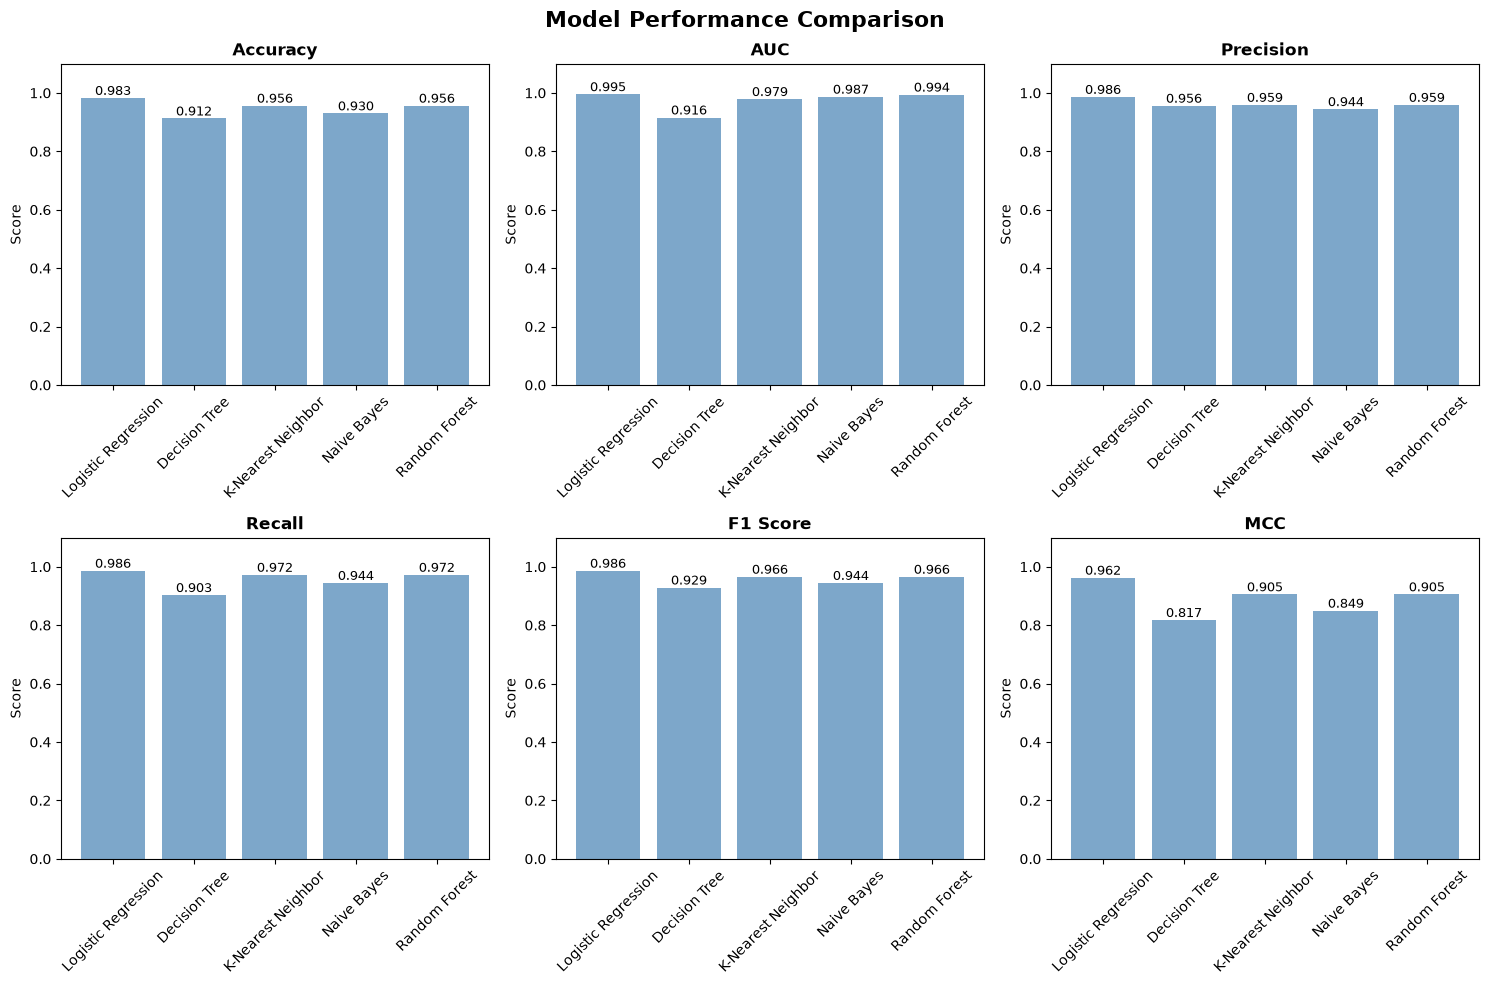

Model comparison chart saved!


In [9]:
# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1 Score', 'MCC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    bars = ax.bar(results_df['Model'], results_df[metric], color='steelblue', alpha=0.7)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison chart saved!")

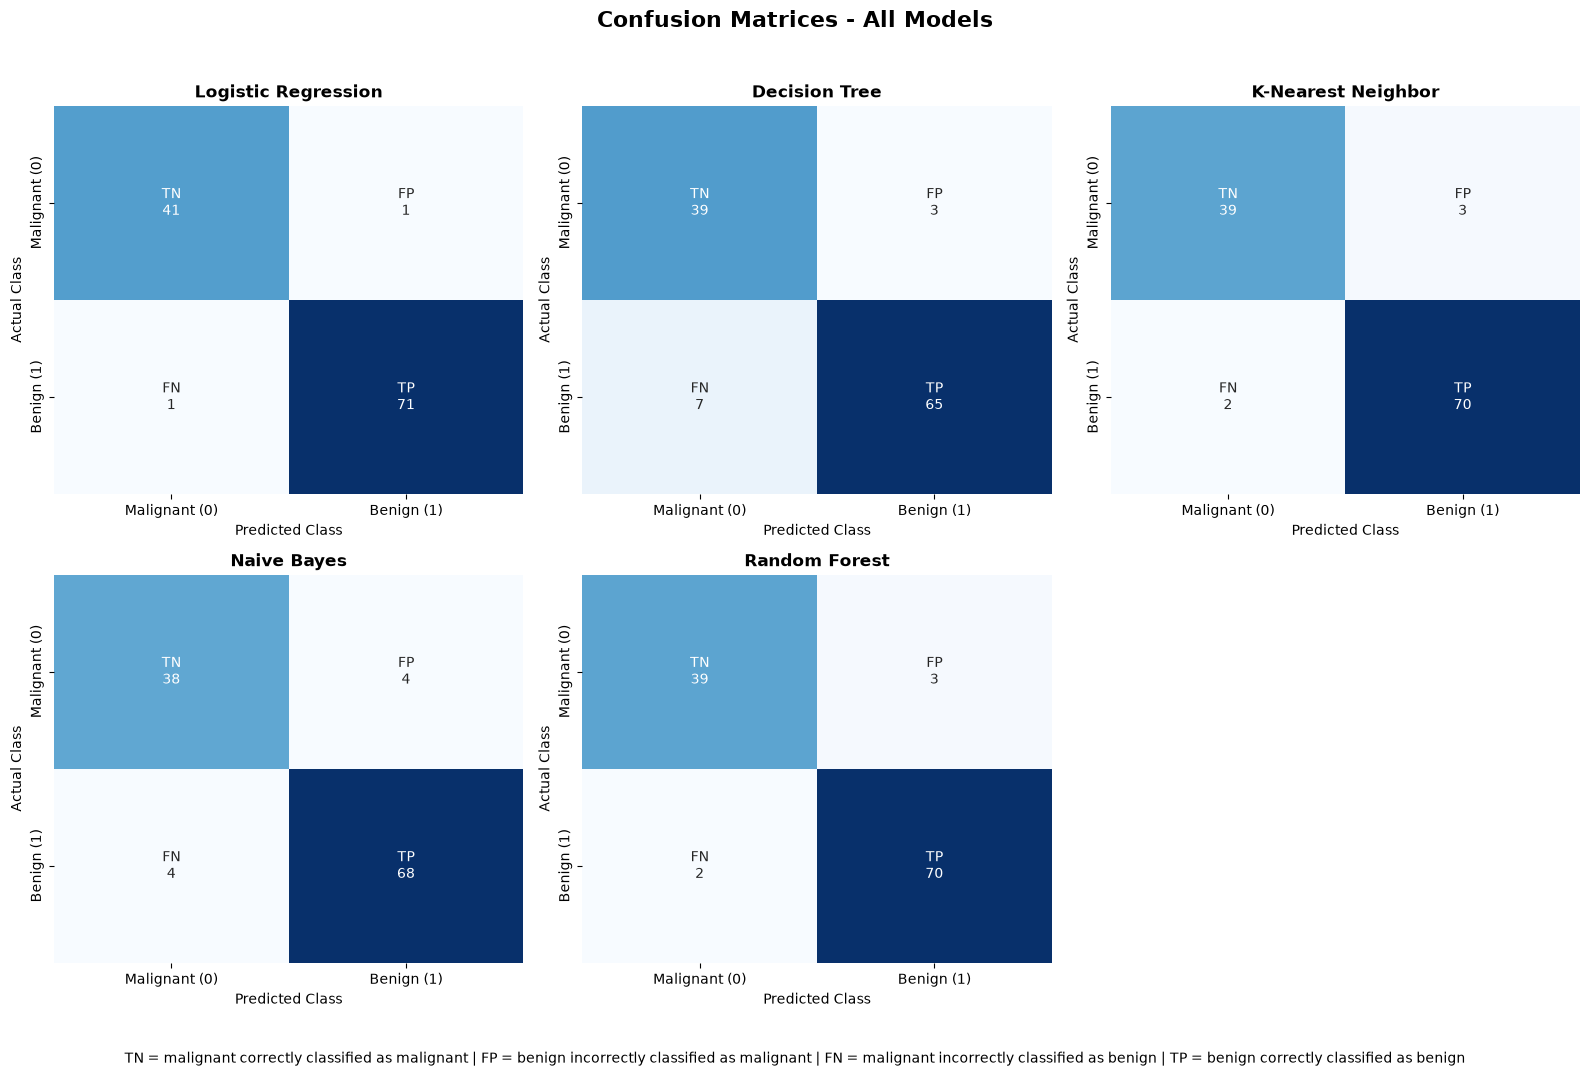

Confusion matrices saved with labeled classes and TN/FP/FN/TP definitions!


In [10]:
# Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

predictions = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'K-Nearest Neighbor': knn_pred,
    'Naive Bayes': nb_pred,
    'Random Forest': rf_pred
}

class_labels = ['Malignant (0)', 'Benign (1)']

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, y_pred)
    cell_labels = np.array([
        [f'TN\n{cm[0, 0]}', f'FP\n{cm[0, 1]}'],
        [f'FN\n{cm[1, 0]}', f'TP\n{cm[1, 1]}']
    ])
    sns.heatmap(
        cm,
        annot=cell_labels,
        fmt='',
        cmap='Blues',
        ax=ax,
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        annot_kws={'fontsize': 10}
    )
    ax.set_title(model_name, fontweight='bold')
    ax.set_ylabel('Actual Class')
    ax.set_xlabel('Predicted Class')

# Hide the unused sixth subplot
axes[1, 2].axis('off')

fig.text(
    0.5,
    0.02,
    'TN = malignant correctly classified as malignant | '
    'FP = benign incorrectly classified as malignant | '
    'FN = malignant incorrectly classified as benign | '
    'TP = benign correctly classified as benign',
    ha='center',
    va='bottom',
    fontsize=10,
    wrap=True
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('Confusion matrices saved with labeled classes and TN/FP/FN/TP definitions!')

## Step 6: Save Models & Scaler for Deployment

In [11]:
# Create model directory if it doesn't exist
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save all models
for model_name, model_obj in models.items():
    filename = os.path.join(model_dir, f'{model_name.lower().replace("-", "_").replace(" ", "_")}.pkl')
    with open(filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"Saved: {filename}")

# Save scaler
scaler_filename = os.path.join(model_dir, 'scaler.pkl')
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Saved: {scaler_filename}")

# Save results dataframe
results_df.to_csv('model_results.csv', index=False)
print("Saved: model_results.csv")

Saved: models/logistic_regression.pkl
Saved: models/decision_tree.pkl
Saved: models/k_nearest_neighbor.pkl
Saved: models/naive_bayes.pkl
Saved: models/random_forest.pkl
Saved: models/scaler.pkl
Saved: model_results.csv


## Step 7: Save Test Data for Streamlit App

In [12]:
# Save test data with predictions and true labels
test_data_output = X_test.copy()
test_data_output['True_Label'] = y_test.values
test_data_output['Logistic_Regression'] = lr_pred
test_data_output['Decision_Tree'] = dt_pred
test_data_output['KNN'] = knn_pred
test_data_output['Naive_Bayes'] = nb_pred
test_data_output['Random_Forest'] = rf_pred

test_data_output.to_csv('test_data.csv', index=False)
print(f"Test data saved! Shape: {test_data_output.shape}")
print(f"\nFirst few rows:")
print(test_data_output.head())

Test data saved! Shape: (114, 36)

First few rows:
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
256        19.55         28.77          133.60     1207.0          0.09260   
428        11.13         16.62           70.47      381.1          0.08151   
501        13.82         24.49           92.33      595.9          0.11620   
363        16.50         18.29          106.60      838.1          0.09686   
564        21.56         22.39          142.00     1479.0          0.11100   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
256           0.20630         0.17840              0.11440         0.1893   
428           0.03834         0.01369              0.01370         0.1511   
501           0.16810         0.13570              0.06759         0.2275   
363           0.08468         0.05862              0.04835         0.1495   
564           0.11590         0.24390              0.13890         0.1726   

     mean fractal

In [13]:
# Display summary statistics
print("\n" + "="*50)
print("ASSIGNMENT SUMMARY")
print("="*50)
print(f"\nDataset: Breast Cancer Wisconsin")
print(f"Features: {X.shape[1]}")
print(f"Instances: {X.shape[0]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"\nModels Implemented: {len(models)}")
print(f"  - Logistic Regression")
print(f"  - Decision Tree Classifier")
print(f"  - K-Nearest Neighbor Classifier")
print(f"  - Naive Bayes Classifier")
print(f"  - Random Forest (Ensemble)")
print(f"\nMetrics Calculated: 6")
print(f"  - Accuracy")
print(f"  - AUC Score")
print(f"  - Precision")
print(f"  - Recall")
print(f"  - F1 Score")
print(f"  - Matthews Correlation Coefficient (MCC)")
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("\n" + "="*50)


ASSIGNMENT SUMMARY

Dataset: Breast Cancer Wisconsin
Features: 30
Instances: 569
Training samples: 455
Test samples: 114

Models Implemented: 5
  - Logistic Regression
  - Decision Tree Classifier
  - K-Nearest Neighbor Classifier
  - Naive Bayes Classifier
  - Random Forest (Ensemble)

Metrics Calculated: 6
  - Accuracy
  - AUC Score
  - Precision
  - Recall
  - F1 Score
  - Matthews Correlation Coefficient (MCC)

Best Model: Logistic Regression
Best Accuracy: 0.9825

